**Exploratory Data Analysis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/sample_data/Nassau_Candy_Cleaned.csv")
df["Order Date"]=pd.to_datetime(df["Order Date"],errors="coerce")
sns.set_theme(style="whitegrid")


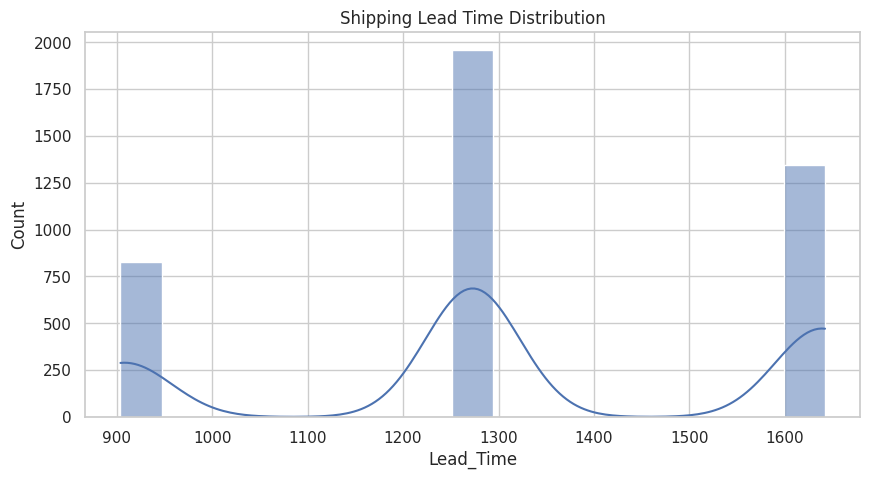

In [ ]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce", dayfirst=True)
df["Lead_Time"] = (df["Ship Date"] - df["Order Date"]).dt.days
fig,ax=plt.subplots(figsize=(10,5)); sns.histplot(df["Lead_Time"].dropna(),kde=True,ax=ax); ax.set_title("Shipping Lead Time Distribution"); plt.show()

In [ ]:
region=df.groupby("Region",dropna=False).agg(Sales=("Sales","sum"),Profit=("Gross Profit","sum"),Lead_Time=("Lead_Time","mean")).reset_index()
region

,Region,Sales,Profit,Lead_Time
0,Atlantic,41197.24,26973.70,1323.477329
1,Gulf,22247.26,14700.67,1309.430124
2,Interior,32037.60,21282.49,1310.291411
3,Pacific,46301.53,30485.94,1327.091892


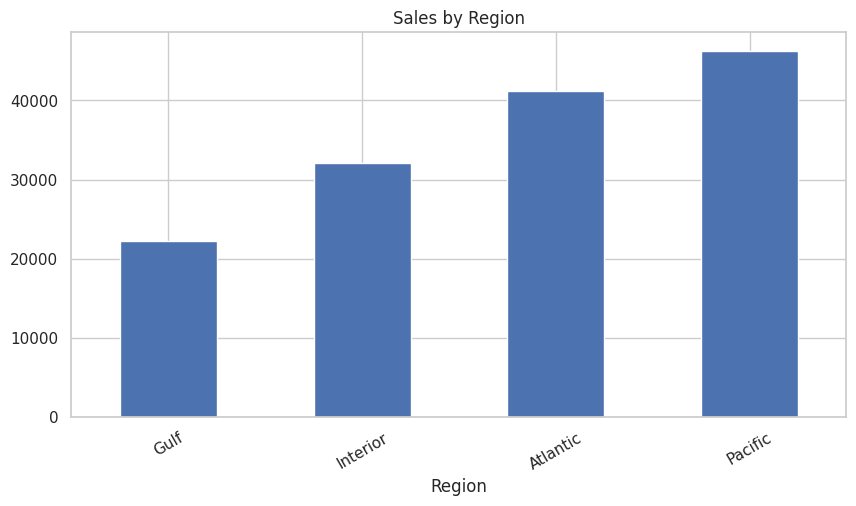

In [ ]:
fig,ax=plt.subplots(figsize=(10,5)); region.sort_values("Sales").plot.bar(x="Region",y="Sales",ax=ax,legend=False); ax.set_title("Sales by Region"); plt.xticks(rotation=30); plt.show()


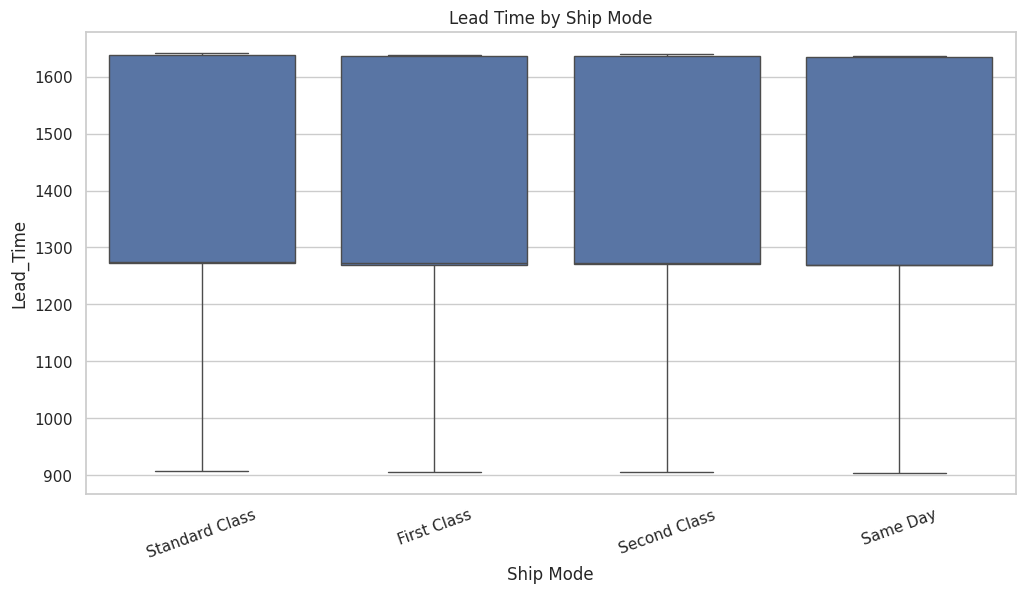

In [ ]:
fig,ax=plt.subplots(figsize=(12,6)); sns.boxplot(data=df,x="Ship Mode",y="Lead_Time",ax=ax); ax.set_title("Lead Time by Ship Mode"); plt.xticks(rotation=20); plt.show()


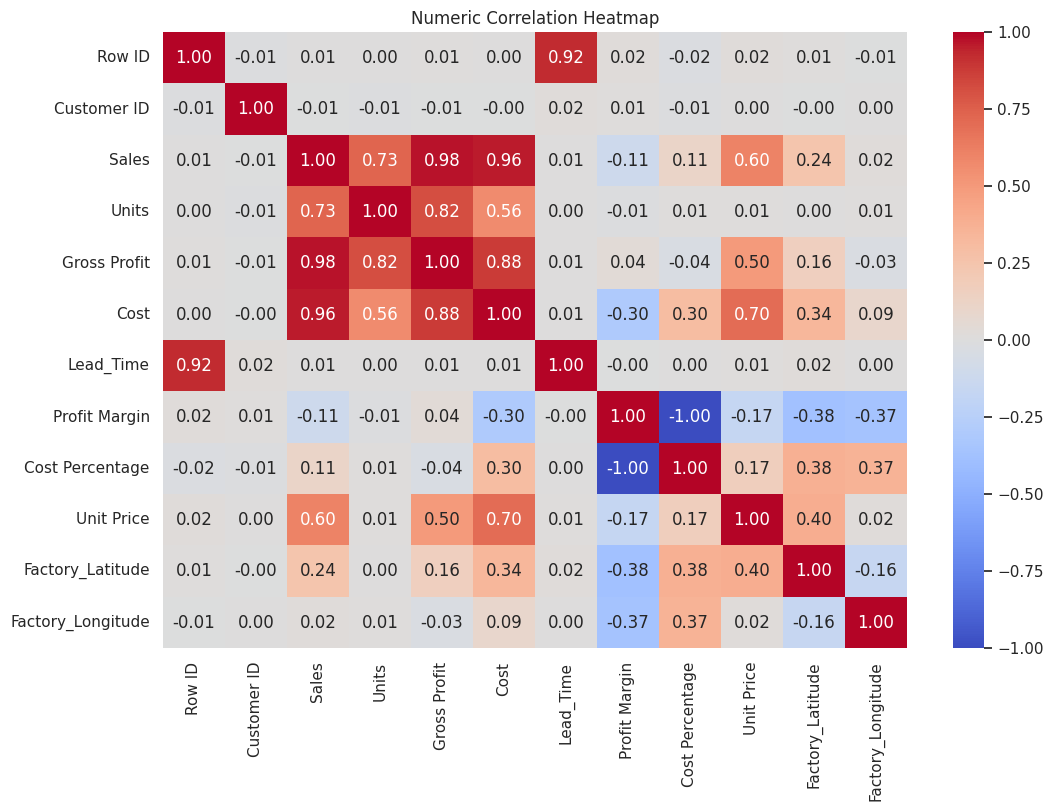

In [ ]:
corr=df.select_dtypes("number").corr()
fig,ax=plt.subplots(figsize=(12,8)); sns.heatmap(corr,annot=True,fmt=".2f",ax=ax,cmap="coolwarm"); ax.set_title("Numeric Correlation Heatmap"); plt.show()


In [ ]:
top=df.groupby("Product Name").agg(Sales=("Sales","sum"),Profit=("Gross Profit","sum"),AvgLead=("Lead_Time","mean")).sort_values("Sales",ascending=False).head(15)
top

,Sales,Profit,AvgLead
Product Name,,,
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,1331.796717
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,1321.177419
Wonka Bar - Milk Chocolate,26867.75,17443.37,1306.015513
Wonka Bar - Fudge Mallows,24890.40,16593.60,1315.152203
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,1319.566845
Lickable Wallpaper,7860.00,3930.00,1346.085714
Kazookles,1205.75,92.75,1309.166667
Wonka Gum,597.50,310.70,1337.052632
Everlasting Gobstopper,130.00,104.00,1271.500000


In [ ]:
factory=df.groupby("Product Name").agg(Orders=("Order ID","nunique"),Sales=("Sales","sum"),Profit=("Gross Profit","sum"),AvgLead=("Lead_Time","mean")).sort_values("Sales",ascending=False)
factory

,Orders,Sales,Profit,AvgLead
Product Name,,,,
Wonka Bar - Triple Dazzle Caramel,1677,28485.00,18610.20,1331.796717
Wonka Bar -Scrumdiddlyumptious,1704,27874.80,19357.50,1321.177419
Wonka Bar - Milk Chocolate,1768,26867.75,17443.37,1306.015513
Wonka Bar - Fudge Mallows,1527,24890.40,16593.60,1315.152203
Wonka Bar - Nutty Crunch Surprise,1529,23574.95,16819.95,1319.566845
Lickable Wallpaper,92,7860.00,3930.00,1346.085714
Kazookles,94,1205.75,92.75,1309.166667
Wonka Gum,118,597.50,310.70,1337.052632
Everlasting Gobstopper,3,130.00,104.00,1271.500000
